# Cardiac Risk Prediction Data Preprocessing

**Dataset:** Heart Disease Prediction (Kaggle) with 270 patients and 13 clinical/demographic features.
**Target:** `Heart Disease` (Presence / Absence)

This notebook covers:
1. Data loading and validation (missing values, duplicates, dtypes)
2. Exploratory Data Analysis (EDA)
3. Encoding categorical variables
4. Train/test split and feature standardization
5. Saving processed data for the modeling notebook (`modeling.ipynb`)

### dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

heart_data = pd.read_csv('Heart_Disease_Prediction.csv')
heart_data.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [3]:
print(f"Shape: {heart_data.shape}")
heart_data.info()

Shape: (270, 14)
<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    str    
dtypes: float64(1), int64

In [4]:
print("Missing values per column:")
print(heart_data.isnull().sum())
print(f"\nDuplicate rows: {heart_data.duplicated().sum()}")

Missing values per column:
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Duplicate rows: 0


In [5]:
heart_data.describe().round(2)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00
mean,54.43,0.68,3.17,131.34,249.66,0.15,1.02,149.68,0.33,1.05,1.59,0.67,4.70
std,9.11,0.47,0.95,17.86,51.69,0.36,1.00,23.17,0.47,1.15,0.61,0.94,1.94
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00
25%,48.00,0.00,3.00,120.00,213.00,0.00,0.00,133.00,0.00,0.00,1.00,0.00,3.00
50%,55.00,1.00,3.00,130.00,245.00,0.00,2.00,153.50,0.00,0.80,2.00,0.00,3.00
75%,61.00,1.00,4.00,140.00,280.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00


### analysis

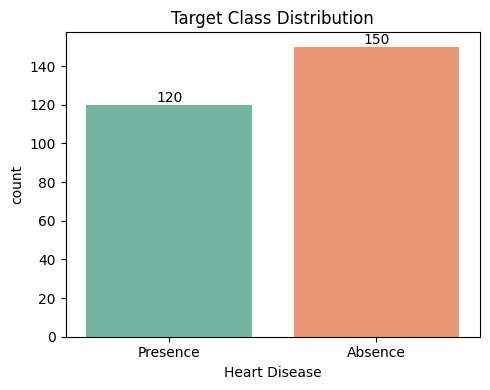

Heart Disease
Absence     0.556
Presence    0.444
Name: proportion, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=heart_data, x='Heart Disease', hue='Heart Disease', palette='Set2', legend=False, ax=ax)
ax.set_title('Target Class Distribution')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

print(heart_data['Heart Disease'].value_counts(normalize=True).round(3))

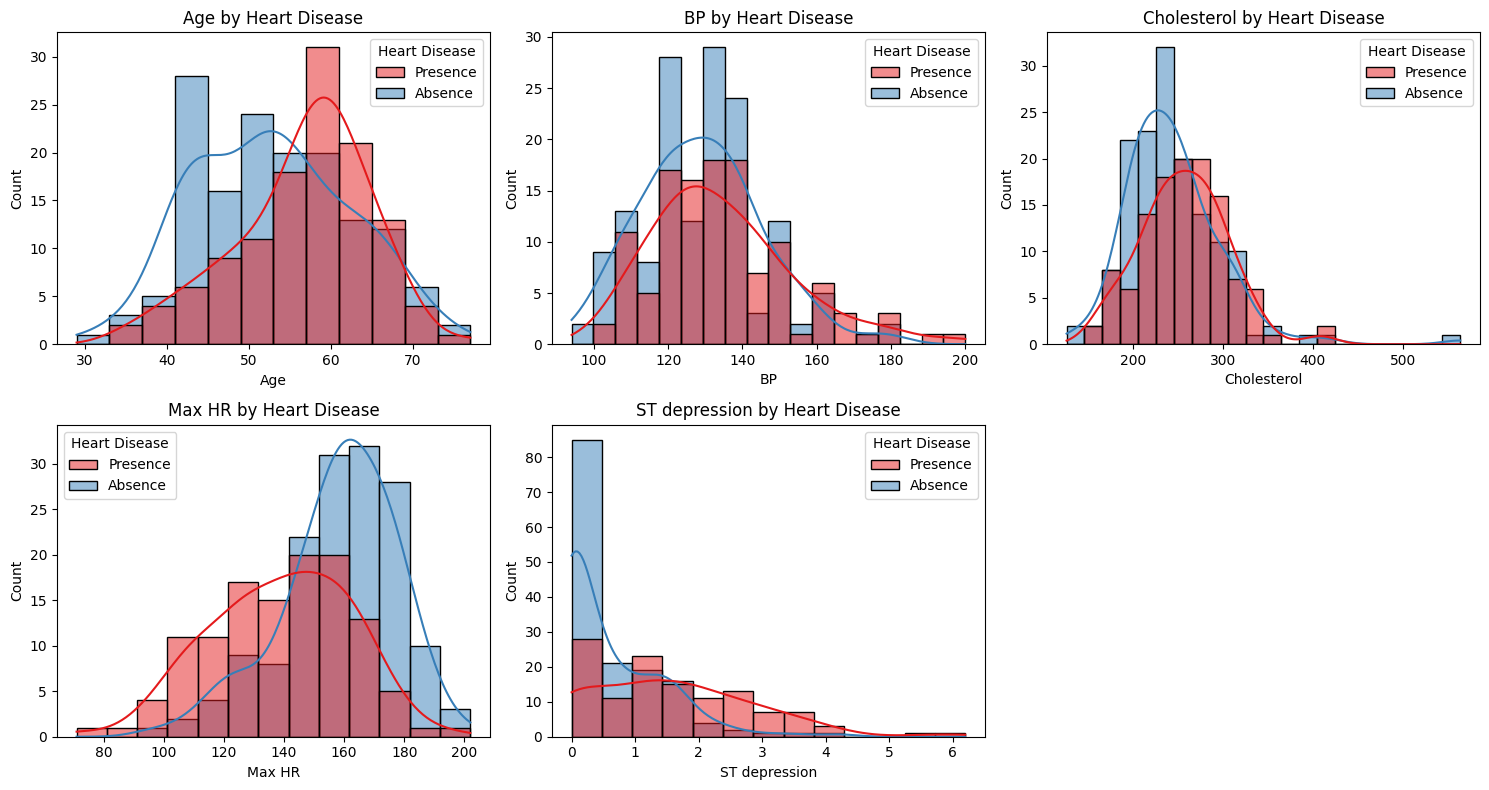

In [7]:
#distributions of numeric features
numeric_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numeric_features):
    sns.histplot(data=heart_data, x=col, hue='Heart Disease', kde=True, ax=ax, palette='Set1', alpha=0.5)
    ax.set_title(f'{col} by Heart Disease')
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

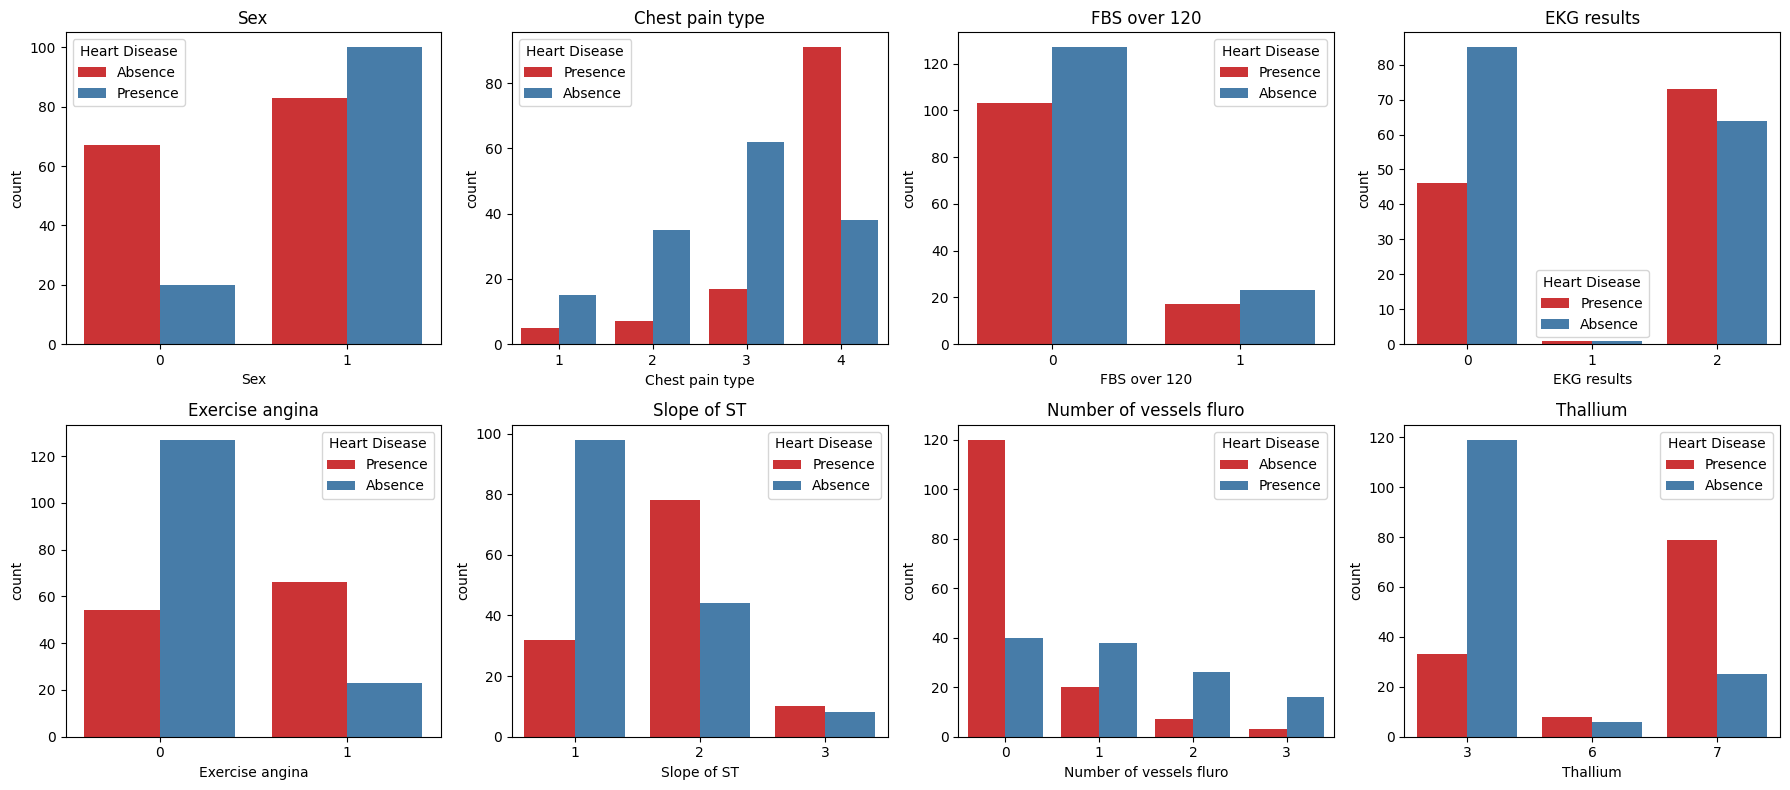

In [8]:
# categorical features vs. target
categorical_features = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results',
                        'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, categorical_features):
    sns.countplot(data=heart_data, x=col, hue='Heart Disease', palette='Set1', ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### correlation heatmap

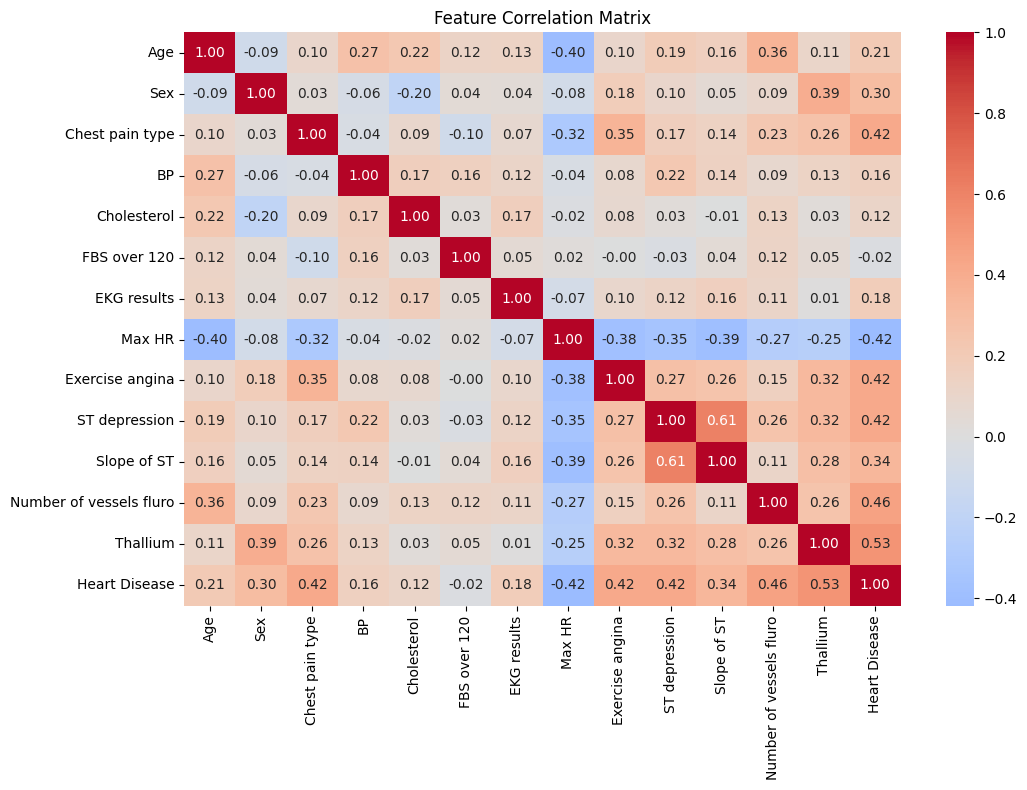

In [9]:
corr_data = heart_data.copy()
corr_data['Heart Disease'] = (corr_data['Heart Disease'] == 'Presence').astype(int)

plt.figure(figsize=(11, 8))
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [10]:
print("Correlation with target (sorted):")
print(corr_data.corr()['Heart Disease'].drop('Heart Disease').sort_values(key=abs, ascending=False).round(3))

Correlation with target (sorted):
Thallium                   0.525
Number of vessels fluro    0.455
Exercise angina            0.419
Max HR                    -0.419
ST depression              0.418
Chest pain type            0.417
Slope of ST                0.338
Sex                        0.298
Age                        0.212
EKG results                0.182
BP                         0.155
Cholesterol                0.118
FBS over 120              -0.016
Name: Heart Disease, dtype: float64


## Preprocessing

- Encoding `Presence` → 1, `Absence` → 0
- One-hot encode nominal categorical features (`Chest pain type`, `EKG results`, `Thallium`). Their numeric codes have no ordinal meaning
- Keep binary and ordinal/count features as-is (`Sex`, `FBS over 120`, `Exercise angina`, `Slope of ST`, `Number of vessels fluro`)

In [12]:
df = heart_data.copy()
df['Heart Disease'] = (df['Heart Disease'] == 'Presence').astype(int)

nominal_cols = ['Chest pain type', 'EKG results', 'Thallium']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True) # produces bool columns; convert to 0/1 integers

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"Shape after encoding: {df.shape}")
print("Original shape: (270, 14); k-1 encoding of 3 nominal features 3 + 2 + 2 = 7 additional columns; 14 + 7 - 3 = 18 columns after encoding")
df.head()

Shape after encoding: (270, 18)
Original shape: (270, 14); k-1 encoding of 3 nominal features 3 + 2 + 2 = 7 additional columns; 14 + 7 - 3 = 18 columns after encoding


,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Heart Disease,Chest pain type_2,Chest pain type_3,Chest pain type_4,EKG results_1,EKG results_2,Thallium_6,Thallium_7
0,70,1,130,322,0,109,0,2.4,2,3,1,0,0,1,0,1,0,0
1,67,0,115,564,0,160,0,1.6,2,0,0,0,1,0,0,1,0,1
2,57,1,124,261,0,141,0,0.3,1,0,1,1,0,0,0,0,0,1
3,64,1,128,263,0,105,1,0.2,2,1,0,0,0,1,0,0,0,1
4,74,0,120,269,0,121,1,0.2,1,1,0,1,0,0,0,1,0,0


### train test split with scalar standardization

80/20 stratified split. The scaler is fit **only on the training set** to avoid data leakage, then applied to both sets.

Scaled copies are used by distance/gradient-based models (Logistic Regression, SVM, k-NN, ANN); tree models (Random Forest, XGBoost) can use the unscaled features.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns='Heart Disease')
y = df['Heart Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scale_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Test class balance:\n{y_test.value_counts(normalize=True).round(3)}")

Train: (216, 17), Test: (54, 17)
Train class balance:
Heart Disease
0    0.556
1    0.444
Name: proportion, dtype: float64
Test class balance:
Heart Disease
0    0.556
1    0.444
Name: proportion, dtype: float64


## 4. Save processed data for the modeling notebook

In [14]:
import os
os.makedirs('processed', exist_ok=True)

X_train.assign(target=y_train).to_csv('processed/train.csv', index=False)
X_test.assign(target=y_test).to_csv('processed/test.csv', index=False)
X_train_scaled.assign(target=y_train).to_csv('processed/train_scaled.csv', index=False)
X_test_scaled.assign(target=y_test).to_csv('processed/test_scaled.csv', index=False)

print('Saved:', os.listdir('processed'))

Saved: ['test.csv', 'test_scaled.csv', 'train.csv', 'train_scaled.csv']
